# BUTQDB: download and load the data

ECG quality dataset from PhysioNet: 18 recordings of about 24 hours each from 15 people, wearing a chest ECG sensor (Bittium Faros 180).
Experts marked every part of each recording with a quality class: **1** = clean, **2** = noisy but heartbeats visible, **3** = unusable.

Run this notebook from the **repo root**. The data goes into `data/`, which is in `.gitignore` and never pushed to GitHub.

## 1. Download the dataset

Downloads all files (about 4.2 GB) from PhysioNet's official mirror into `data/`.
Files that are already there are skipped, so you can run the cell again if it stops halfway.

In [1]:
import urllib.request
from pathlib import Path

BASE = "https://physionet-open.s3.amazonaws.com/butqdb/1.0.0/"   # PhysioNet's official mirror
DATA = Path("data")

def get(path):
    dest = DATA / path
    if dest.exists():
        return
    dest.parent.mkdir(parents=True, exist_ok=True)
    print("downloading", path)
    tmp = dest.with_name(dest.name + ".part")
    urllib.request.urlretrieve(BASE + path, tmp)
    tmp.replace(dest)

get("RECORDS")
get("subject-info.csv")
records = sorted({line.split("/")[0] for line in (DATA / "RECORDS").read_text().split()})

for rec in records:
    for f in ["ECG.hea", "ECG.dat", "ACC.hea", "ACC.dat", "ANN.csv"]:
        get(f"{rec}/{rec}_{f}")

print("done:", len(records), "records")

downloading RECORDS
downloading subject-info.csv
downloading 100001/100001_ECG.hea
downloading 100001/100001_ECG.dat
downloading 100001/100001_ACC.hea
downloading 100001/100001_ACC.dat
downloading 100001/100001_ANN.csv
downloading 100002/100002_ECG.hea
downloading 100002/100002_ECG.dat
downloading 100002/100002_ACC.hea
downloading 100002/100002_ACC.dat
downloading 100002/100002_ANN.csv
downloading 103001/103001_ECG.hea
downloading 103001/103001_ECG.dat
downloading 103001/103001_ACC.hea
downloading 103001/103001_ACC.dat
downloading 103001/103001_ANN.csv
downloading 103002/103002_ECG.hea
downloading 103002/103002_ECG.dat
downloading 103002/103002_ACC.hea
downloading 103002/103002_ACC.dat
downloading 103002/103002_ANN.csv
downloading 103003/103003_ECG.hea
downloading 103003/103003_ECG.dat
downloading 103003/103003_ACC.hea
downloading 103003/103003_ACC.dat
downloading 103003/103003_ANN.csv
downloading 104001/104001_ECG.hea
downloading 104001/104001_ECG.dat
downloading 104001/104001_ACC.hea

## 2. Function to load one recording

Each recording is 24 hours long, so we load only a time slice (default: the first 10 minutes).

- **ECG**: heart signal, 1000 samples per second, in µV
- **ACC**: movement on 3 axes (x, y, z), 100 samples per second, in mg
- **Annotations**: the experts' quality labels as `start`, `end` (sample numbers, counting from 1) and `quality` (0 = not annotated)

In [2]:
import wfdb
import pandas as pd

def load_record(rec, start_min=0, minutes=10):
    a = int(start_min * 60 * 1000)          # ECG is 1000 Hz
    b = a + int(minutes * 60 * 1000)
    ecg = wfdb.rdrecord(f"data/{rec}/{rec}_ECG", sampfrom=a, sampto=b)
    acc = wfdb.rdrecord(f"data/{rec}/{rec}_ACC", sampfrom=a // 10, sampto=b // 10)   # ACC is 100 Hz
    ann = pd.read_csv(f"data/{rec}/{rec}_ANN.csv", header=None).iloc[:, 9:12].dropna().astype(int)
    ann.columns = ["start", "end", "quality"]   # consensus labels, sample numbers start at 1
    return ecg, acc, ann

subjects = pd.read_csv("data/subject-info.csv", sep=";")

## 3. Check that every recording loads

Loads 1 minute from each recording and prints the sampling rates, the units and how many annotated segments each quality class has.
The table below lists the participants (sex, age, height, weight, smoker).
Note: the first 3 digits of the ID are the person, so `100001` and `100002` are the same person.

In [3]:
for rec in records:
    ecg, acc, ann = load_record(rec, minutes=1)
    print(rec, ecg.fs, ecg.units, acc.fs, acc.units, ann["quality"].value_counts().to_dict())

subjects

100001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 382, 1: 379, 3: 2}
100002 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {1: 115, 2: 114, 0: 3}
103001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 91, 1: 89, 0: 3, 3: 3}
103002 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {1: 56, 2: 54, 0: 3}
103003 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {1: 88, 2: 86, 0: 3}
104001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {1: 53, 2: 51, 0: 3}
105001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 676, 1: 676, 3: 2}
111001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 1356, 1: 1085, 3: 298}
113001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 105, 1: 90, 3: 18, 0: 4}
114001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 10, 1: 10, 0: 5, 3: 2}
115001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {1: 74, 2: 73, 0: 3}
118001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {1: 61, 2: 61, 0: 3}
121001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 85, 1: 85, 0: 3}
122001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 12, 1: 12, 0: 3, 3: 1}
123001 1000 ['uV'] 100 ['mg', 'mg', 'mg'] {2: 56, 1: 54, 0: 3, 3: 2}
124001 1000

,ID,Gender,Age,Height,Weight,Smoker
0,100001,F,28,173,70,0
1,100002,F,28,173,70,0
2,103001,M,21,184,68,0
3,103002,M,21,184,68,0
4,103003,M,21,184,68,0
5,104001,F,21,174,60,0
6,105001,M,22,184,80,0
7,111001,F,28,168,49,0
8,113001,F,23,163,50,0
9,114001,F,24,156,43,0


## 4. How much data is there per quality class?

Collects the experts' labels from all recordings into one table and adds up the minutes per quality class for each person.
Most people only have part of their 24 hours labelled, and class 3 (unusable) is the rarest.

In [4]:
labels = []
for rec in records:
    ann = pd.read_csv(f"data/{rec}/{rec}_ANN.csv", header=None).iloc[:, 9:12].dropna().astype(int)
    ann.columns = ["start", "end", "quality"]
    ann["record"] = rec
    ann["subject"] = rec[:3]
    ann["minutes"] = (ann["end"] - ann["start"] + 1) / 1000 / 60
    labels.append(ann)

labels = pd.concat(labels, ignore_index=True)
labels = labels[labels["quality"] > 0]          # drop "not annotated"

summary = labels.pivot_table(index="subject", columns="quality", values="minutes",
                             aggfunc="sum", fill_value=0).round(1)
summary

quality,1,2,3
subject,,,
100,1022.3,465.4,3.7
103,99.1,20.7,0.1
104,26.5,13.5,0.0
105,971.4,558.6,789.2
111,633.7,810.1,67.0
113,39.6,18.7,1.7
114,38.7,9.3,14.0
115,27.3,12.7,0.0
118,25.4,14.6,0.0


## 5. What does each quality class look like?

Plots 10 seconds of ECG from one segment of each class, so we can see the difference with our own eyes.
Class 1 should show clear heartbeats, class 2 heartbeats with noise, class 3 mostly noise.

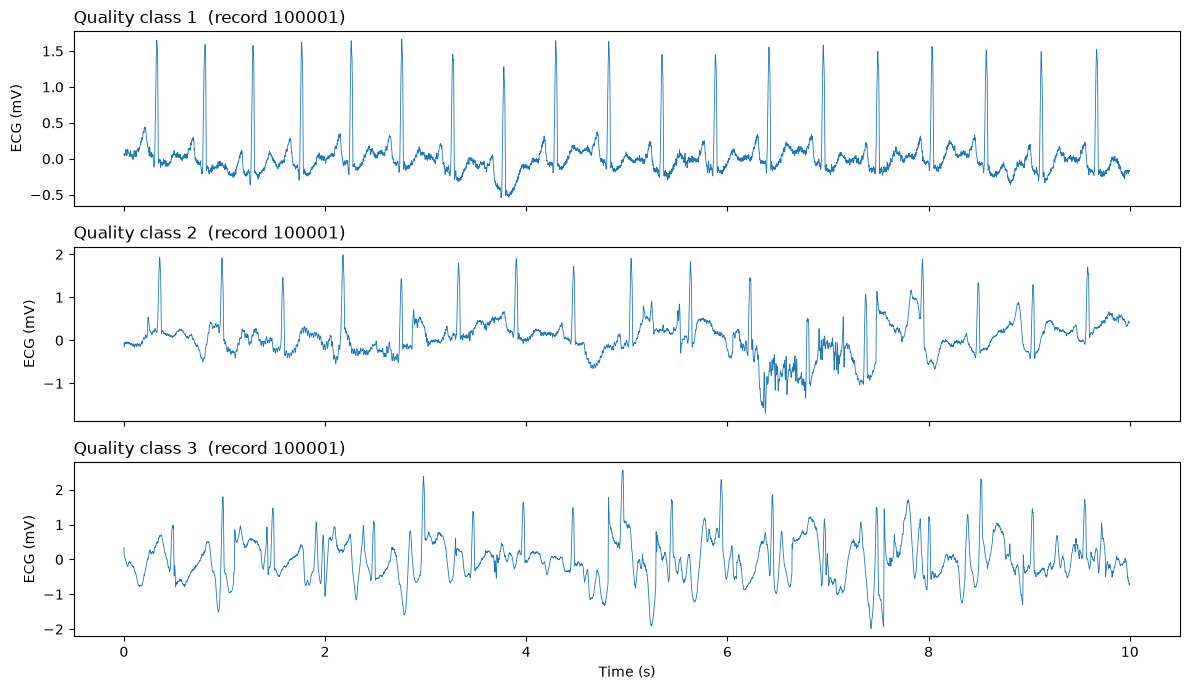

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, q in zip(axes, [1, 2, 3]):
    seg = labels[(labels["quality"] == q) & (labels["minutes"] >= 1)].iloc[0]
    ecg, acc, _ = load_record(seg["record"], start_min=(seg["start"] - 1) / 60000, minutes=10 / 60)
    t = np.arange(ecg.sig_len) / ecg.fs
    ax.plot(t, ecg.p_signal[:, 0] / 1000, lw=0.6)
    ax.set_title(f"Quality class {q}  (record {seg['record']})", loc="left")
    ax.set_ylabel("ECG (mV)")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()